# What makes people happy? Can you find Dytopia?

The `World Happiness Report` is a landmark survey of the state of global happiness that ranks 156 countries by how happy their citizens perceive themselves to be. Over the last year’s, `World Happiness Report` focuses on happiness and the community: how happiness has evolved over the past dozen years, with a focus on the technologies, social norms, conflicts and government policies that have driven those changes.

<img src="https://allthatsinteresting.com/wordpress/wp-content/uploads/2016/03/giphy-4.gif" width="700px">

**Dataset information**

    The information in the datasets is based on answers to the most life evaluation address inquired within the survey. This address, known as the Cantril step, asks respondents to think of a step with the most excellent conceivable life for them being a 10 and the most exceedingly bad conceivable life being a and to rate their claim current lives on that scale.


The Happiness Score is explained by the following factors:

- `Overall rank`: happiness rank of the different countries
- `Country o region`
- `Score`:  is a national average of the responses to the main life evaluation question asked in the Gallup World Poll (GWP), which uses the Cantril Ladder. Ranges from [0-10]
- `GDP per capita`
- `Healthy Life Expectancy`: score that goes from [0-1], being 1 the ones that have more confidence in terms of healthy life
- `Social support`: it indicates how people are appreciating the social support by governments, and it that ranges from [0-2]
- `Freedom to make life choices` score that ranges from 0 to 1, being 1 the ones that feel more free
- `Generosity`:score that ranges from 0 to 1, being 1 the ones that feel more generosity
- `Perceptions of corruption`: perception of corruption on the country that it goes from  0 to 1. The higher this value is the lower perception of corruption
- `year`  


>dataset: `Ex2.2._Happiness-Score.csv`

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Exercise 1.Tell a story with your dataset, to try to answer the following question:

>"Which factors are more important to live a happier life? As a result, people and countries can focus on the more significant factors to achieve a higher happiness level "

To achieve this goal, use the different funcionalities from the visualization libraries that you have seen in the module.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
happiness_df= pd.read_csv('/content/drive/MyDrive/BIModule_Project/Ex2.2._Happiness-Score.csv')
new_happiness_df= happiness_df.copy()
new_happiness_df.head()

,Unnamed: 0.1,Unnamed: 0,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,0,0,1,Finland,7.632,1.305,1.592,NaN,0.681,0.202,0.393,2018
1,1,1,2,Norway,7.594,1.456,1.582,NaN,0.686,0.286,0.340,2018
2,2,2,3,Denmark,7.555,1.351,1.590,NaN,0.683,0.284,0.408,2018
3,3,3,4,Iceland,7.495,1.343,1.644,NaN,0.677,0.353,0.138,2018
4,4,4,5,Switzerland,7.487,1.420,1.549,NaN,0.660,0.256,0.357,2018


In [4]:
#We want to find countries with a high Happiness Score (Score greater than 7.0)
high_score_condition = new_happiness_df['Score'] > 7.0

# 2. Check the boolean mask itself (Shows True/False for every row)
print("--- Boolean Mask (First 5 Rows) ---")
print(high_score_condition.head())

# 3. Apply the boolean mask to filter the DataFrame
new_happiness_df_high_score = new_happiness_df[high_score_condition]

# 4. Print the results of the filtered DataFrame
print("\n--- Filtered DataFrame Results (Countries with Score > 7.0) ---")
print(f"Original DataFrame shape: {new_happiness_df.shape}")
print(f"Filtered DataFrame shape: {new_happiness_df_high_score.shape}")
print(new_happiness_df_high_score[['Country or region', 'Score', 'year']].head())

--- Boolean Mask (First 5 Rows) ---
0    True
1    True
2    True
3    True
4    True
Name: Score, dtype: bool

--- Filtered DataFrame Results (Countries with Score > 7.0) ---
Original DataFrame shape: (312, 12)
Filtered DataFrame shape: (29, 12)
  Country or region  Score  year
0           Finland  7.632  2018
1            Norway  7.594  2018
2           Denmark  7.555  2018
3           Iceland  7.495  2018
4       Switzerland  7.487  2018


In [5]:
new_happiness_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0.1                  312 non-null    int64  
 1   Unnamed: 0                    312 non-null    int64  
 2   Overall rank                  312 non-null    int64  
 3   Country or region             312 non-null    object 
 4   Score                         312 non-null    float64
 5   GDP per capita                312 non-null    float64
 6   Social support                312 non-null    float64
 7   Healthy life expectancy       7 non-null      float64
 8   Freedom to make life choices  312 non-null    float64
 9   Generosity                    312 non-null    float64
 10  Perceptions of corruption     311 non-null    float64
 11  year                          312 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 29.4+ KB


In [6]:
new_happiness_df.describe()

,Unnamed: 0.1,Unnamed: 0,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,7.000000,312.000000,312.000000,311.000000,312.000000
mean,155.500000,77.500000,78.500000,5.391506,0.898298,1.211026,0.038571,0.423538,0.182926,0.111299,2018.500000
std,90.210864,45.104737,45.104737,1.114631,0.394592,0.300310,0.035213,0.156024,0.096739,0.095365,0.500803
min,0.000000,0.000000,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000
25%,77.750000,38.750000,39.750000,4.514250,0.609500,1.055750,0.005000,0.322500,0.108750,0.050000,2018.000000
50%,155.500000,77.500000,78.500000,5.379500,0.960000,1.265500,0.048000,0.449500,0.175500,0.082000,2018.500000
75%,233.250000,116.250000,117.250000,6.176000,1.219500,1.457500,0.066000,0.540250,0.245000,0.140500,2019.000000
max,311.000000,155.000000,156.000000,7.769000,2.096000,1.644000,0.080000,0.724000,0.598000,0.457000,2019.000000


In [6]:
new_happiness_df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64


In [7]:
new_happiness_df.shape

(312, 12)

In [8]:
new_happiness_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Overall rank', 'Country or region',
       'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'year'],
      dtype='object')

In [9]:
new_happiness_df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,305
Freedom to make life choices,0
Generosity,0


In [10]:
new_happiness_df.duplicated().sum()

np.int64(0)

In [11]:
country_counts = new_happiness_df['Country or region'].value_counts(dropna=False)
print(country_counts)
print("-" * 50)
year_counts = new_happiness_df['year'].value_counts(dropna=False)
print(year_counts)

Country or region
Finland            2
Norway             2
Denmark            2
Iceland            2
Switzerland        2
                  ..
Sudan              1
North Macedonia    1
Gambia             1
Swaziland          1
Comoros            1
Name: count, Length: 160, dtype: int64
--------------------------------------------------
year
2018    156
2019    156
Name: count, dtype: int64


In [14]:
macedonia_data = new_happiness_df[new_happiness_df['Country or region'].isin(['North Macedonia', 'Macedonia'])]
print(macedonia_data[['Country or region', 'year']])

    Country or region  year
88          Macedonia  2018
239   North Macedonia  2019


Following I standardized these two entries to a single name --> North Macedonia

In [12]:
new_happiness_df['Country or region'] = new_happiness_df['Country or region'].replace('Macedonia', 'North Macedonia')
verification = new_happiness_df[new_happiness_df['Country or region'] == 'North Macedonia'][['Country or region', 'year']]
print(verification)
print(new_happiness_df['Country or region'].value_counts().loc['North Macedonia'])

    Country or region  year
88    North Macedonia  2018
239   North Macedonia  2019
2


No obvious spelling mistakes, leading/trailing spaces, or mixed-case issues (e.g., "finland" vs. "Finland") were found in the Country or region column. All country names appear to be properly capitalized and consistently spelled.

The year column is entirely consistent, containing only the integer values $\text{2018}$ and $\text{2019}$.

No other columns were identified as categorical variables (they were all numerical/float).

In [13]:
new_happiness_df_clean = new_happiness_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
new_happiness_df_clean.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,1,Finland,7.632,1.305,1.592,NaN,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,NaN,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,NaN,0.683,0.284,0.408,2018
3,4,Iceland,7.495,1.343,1.644,NaN,0.677,0.353,0.138,2018
4,5,Switzerland,7.487,1.420,1.549,NaN,0.660,0.256,0.357,2018


In [14]:
new_happiness_df_clean = new_happiness_df_clean.drop(columns=['Healthy life expectancy'])
new_happiness_df_clean.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,1,Finland,7.632,1.305,1.592,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,0.683,0.284,0.408,2018
3,4,Iceland,7.495,1.343,1.644,0.677,0.353,0.138,2018
4,5,Switzerland,7.487,1.420,1.549,0.660,0.256,0.357,2018


In [15]:
new_happiness_df_clean = new_happiness_df_clean.dropna(subset=['Perceptions of corruption'])
new_happiness_df_clean.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,1,Finland,7.632,1.305,1.592,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,0.683,0.284,0.408,2018
3,4,Iceland,7.495,1.343,1.644,0.677,0.353,0.138,2018
4,5,Switzerland,7.487,1.420,1.549,0.660,0.256,0.357,2018


In [16]:
print(new_happiness_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 311 entries, 0 to 311
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  311 non-null    int64  
 1   Country or region             311 non-null    object 
 2   Score                         311 non-null    float64
 3   GDP per capita                311 non-null    float64
 4   Social support                311 non-null    float64
 5   Freedom to make life choices  311 non-null    float64
 6   Generosity                    311 non-null    float64
 7   Perceptions of corruption     311 non-null    float64
 8   year                          311 non-null    int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 24.3+ KB
None


In [17]:
new_happiness_df_clean[['Overall rank', 'Score', 'GDP per capita', 'Social support',
                        'Freedom to make life choices', 'Generosity',
                        'Perceptions of corruption', 'year']].describe()

,Overall rank,Score,GDP per capita,Social support,Freedom to make life choices,Generosity,Perceptions of corruption,year
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,78.688103,5.387061,0.894447,1.212424,0.423987,0.182916,0.111299,2018.501608
std,45.054689,1.113653,0.389311,0.299774,0.156074,0.096895,0.095365,0.500803
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000
25%,40.000000,4.512500,0.608000,1.057000,0.325500,0.108500,0.050000,2018.000000
50%,79.000000,5.373000,0.960000,1.266000,0.450000,0.175000,0.082000,2019.000000
75%,117.500000,6.173500,1.214500,1.458000,0.540500,0.245000,0.140500,2019.000000
max,156.000000,7.769000,1.684000,1.644000,0.724000,0.598000,0.457000,2019.000000


Based on the data ranges for all numerical columns, the dataset does not contain any impossible values such as negative scores or future dates.

I validated the data by checking the minimum and maximum values for all relevant metrics.

The minimum value of $\mathbf{0.000}$ for several of the component metrics (like '`GDP per capita`' or '`Social support`') is considered valid in the context of this structured dataset. Since these columns represent a country's contribution to the overall happiness score, a value of $0.000$ indicates the lowest possible contribution on the normalized scale used in the index, not a true impossibility.

In [18]:
for cols in new_happiness_df_clean.columns:
  print(new_happiness_df_clean[cols].value_counts())

Overall rank
1      2
2      2
3      2
4      2
5      2
      ..
153    2
154    2
155    2
156    2
20     1
Name: count, Length: 156, dtype: int64
Country or region
Finland                 2
Norway                  2
Denmark                 2
Iceland                 2
Switzerland             2
                       ..
Sudan                   1
United Arab Emirates    1
Gambia                  1
Swaziland               1
Comoros                 1
Name: count, Length: 159, dtype: int64
Score
4.707    2
4.166    2
5.890    2
5.208    2
6.374    2
        ..
4.806    1
4.880    1
4.933    1
4.975    1
4.657    1
Name: count, Length: 294, dtype: int64
GDP per capita
0.960    4
1.340    3
0.332    3
1.016    2
0.807    2
        ..
0.710    1
0.557    1
0.949    1
0.853    1
0.900    1
Name: count, Length: 275, dtype: int64
Social support
1.538    3
1.504    3
1.438    3
1.465    3
1.125    3
        ..
1.149    1
1.069    1
1.039    1
1.058    1
0.572    1
Name: count, Length: 265, dty

In [19]:
# --- 1. IQR Method Functions ---
def iqr_outlier_counts(new_happiness_df_clean, column):
    Q1 = new_happiness_df_clean[column].quantile(0.25)
    Q3 = new_happiness_df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = new_happiness_df_clean[(new_happiness_df_clean[column] < lower_bound) | (new_happiness_df_clean[column] > upper_bound)].shape[0]
    return outlier_count, lower_bound, upper_bound

# Moved outside the function definition
column_to_check = ['Score', 'GDP per capita', 'Social support',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

# Iterate over the columns to apply the function and print results
for col in column_to_check:
    count, lower_fence, upper_fence = iqr_outlier_counts(new_happiness_df_clean, col)
    print(col)
    print(count)
    print(lower_fence)
    print(upper_fence)
    print("\n")

Score
0
2.021000000000001
8.665


GDP per capita
0
-0.3017500000000003
2.1242500000000004


Social support
7
0.45549999999999957
2.0595000000000008


Freedom to make life choices
2
0.003000000000000058
0.863


Generosity
4
-0.09625000000000002
0.44975


Perceptions of corruption
31
-0.08575
0.27625




In [21]:
def iqr_cap_outliers(new_happiness_df_clean, column, lower_bound, upper_bound):
    """Caps outliers at the IQR fences."""
    new_happiness_df_clean[column] = np.where(new_happiness_df_clean[column] < lower_bound, lower_bound, new_happiness_df_clean[column])
    new_happiness_df_clean[column] = np.where(new_happiness_df_clean[column] > upper_bound, upper_bound, new_happiness_df_clean[column])
    return new_happiness_df_clean

# Moved outside the function definition
column_to_check = ['Score', 'GDP per capita', 'Social support',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
new_happiness_df_capped = new_happiness_df_clean.copy()

print("--- Outlier Detection and Capping Results ---")

# Iterate over the columns to calculate bounds and apply capping
for col in column_to_check:
    count, lower_fence, upper_fence = iqr_outlier_counts(new_happiness_df_clean, col)

# Apply Capping only if outliers exist for the current column
    if count > 0:
        new_happiness_df_capped = iqr_cap_outliers(new_happiness_df_capped, col, lower_fence, upper_fence)
        print(f"Capped {count} outliers in column '{col}'.")
        print(f"  IQR Fences used: Lower={lower_fence:.4f}, Upper={upper_fence:.4f}\n")
    else:
        print(f"No outliers found in column '{col}'.\n")


--- Outlier Detection and Capping Results ---
No outliers found in column 'Score'.

No outliers found in column 'GDP per capita'.

Capped 7 outliers in column 'Social support'.
  IQR Fences used: Lower=0.4555, Upper=2.0595

Capped 2 outliers in column 'Freedom to make life choices'.
  IQR Fences used: Lower=0.0030, Upper=0.8630

Capped 4 outliers in column 'Generosity'.
  IQR Fences used: Lower=-0.0963, Upper=0.4497

Capped 31 outliers in column 'Perceptions of corruption'.
  IQR Fences used: Lower=-0.0858, Upper=0.2762



In [22]:
# Define the numerical columns again for self-containment of this cell
numerical_cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Check the effect of capping on the capped columns by comparing min/max
print("\nComparison of Min/Max Values (Before vs. After Capping):")
comparison_data = []
for col in numerical_cols:
    # Get original bounds
    original_min = new_happiness_df_clean[col].min()
    original_max = new_happiness_df_clean[col].max()

    # Get capped bounds
    capped_min = new_happiness_df_capped [col].min()
    capped_max = new_happiness_df_capped [col].max()

    # Only report if a change was made
    if original_min != capped_min or original_max != capped_max:
         comparison_data.append({
            'Factor': col,
            'Original Min': f"{original_min:.4f}",
            'Capped Min': f"{capped_min:.4f}",
            'Original Max': f"{original_max:.4f}",
            'Capped Max': f"{capped_max:.4f}"
        })

new_happiness_df_comparison = pd.DataFrame(comparison_data)
if not new_happiness_df_comparison.empty:
    print(new_happiness_df_comparison.to_string(index=False))
else:
    print("No factors had outliers detected by the IQR method.")


Comparison of Min/Max Values (Before vs. After Capping):
                      Factor Original Min Capped Min Original Max Capped Max
              Social support       0.0000     0.4555       1.6440     1.6440
Freedom to make life choices       0.0000     0.0030       0.7240     0.7240
                  Generosity       0.0000     0.0000       0.5980     0.4497
   Perceptions of corruption       0.0000     0.0000       0.4570     0.2762


In [23]:
# --- Z-score Method Function ---
def zscore_outlier_counts(new_happiness_df_clean, column, threshold=3):
    """Calculates the number of outliers using the Z-score (|Z| > threshold)."""
    # Calculate Z-scores
    z_scores = (new_happiness_df_clean[column] - new_happiness_df_clean[column].mean()) / new_happiness_df_clean[column].std()

    # Count outliers
    outlier_count = new_happiness_df_clean[np.abs(z_scores) > threshold].shape[0]
    # The original function attempted to return the function name; corrected to return the count.
    return outlier_count

# Numerical columns to check
numerical_cols = ['Score', 'GDP per capita', 'Social support',
                  'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

print("--- Z-score Outlier Detection Results (|Z| > 3) ---")

outlier_report = {}

# Loop through columns and print results
for col in numerical_cols:
    # Call the function
    count = zscore_outlier_counts(new_happiness_df_clean, col)

    # Store and print the result
    outlier_report[col] = count
    print(f"Factor '{col}': {count} outliers")

# Convert to DataFrame for clean presentation
report_df = pd.DataFrame(outlier_report.items(), columns=['Factor', 'Z-score Outliers Count (|Z|>3)'])
print("\nSummary Report:")
print(report_df.to_string(index=False))

--- Z-score Outlier Detection Results (|Z| > 3) ---
Factor 'Score': 0 outliers
Factor 'GDP per capita': 0 outliers
Factor 'Social support': 2 outliers
Factor 'Freedom to make life choices': 0 outliers
Factor 'Generosity': 4 outliers
Factor 'Perceptions of corruption': 6 outliers

Summary Report:
                      Factor  Z-score Outliers Count (|Z|>3)
                       Score                               0
              GDP per capita                               0
              Social support                               2
Freedom to make life choices                               0
                  Generosity                               4
   Perceptions of corruption                               6


In [24]:
print("--- Comparison of Factor Statistics Before and After IQR Capping ---")

# Iterate and compare statistics for each capped column
for col in numerical_cols:
    # 1. Calculate the fences from the original data (use a dummy variable for count if not needed)
    outlier_count, lower_fence, upper_fence = iqr_outlier_counts(new_happiness_df_clean, col)

    # 2. Combine descriptive stats for comparison
    new_happiness_df_comparison_per_col = pd.DataFrame({
        'Metric': ['Min', 'Max', 'Mean', 'Std'],
        'Original': [
            new_happiness_df_clean[col].min(),
            new_happiness_df_clean[col].max(),
            new_happiness_df_clean[col].mean(),
            new_happiness_df_clean[col].std()
        ],
        'Capped': [
            new_happiness_df_capped[col].min(),
            new_happiness_df_capped[col].max(),
            new_happiness_df_capped[col].mean(),
            new_happiness_df_capped[col].std()
        ]
    }).set_index('Metric')

    # 3. Print the results
    print(f"\n=============================================")
    print(f"Factor: {col}")
    print(f"Capping Fences: Lower={lower_fence:.4f}, Upper={upper_fence:.4f}")
    print("=============================================")
    print(new_happiness_df_comparison_per_col.to_string(float_format='%.4f'))

    # 4. Highlight the main changes
    min_change = new_happiness_df_clean[col].min() != new_happiness_df_capped[col].min()
    max_change = new_happiness_df_clean[col].max() != new_happiness_df_capped[col].max()

    if min_change and max_change:
        print(f"Note: Outliers were capped on BOTH the low and high ends.")
    elif min_change:
        print(f"Note: Outliers were capped on the LOW end.")
    elif max_change:
        print(f"Note: Outliers were capped on the HIGH end.")
    else:
        print(f"Note: No visual change in min/max (outliers were extreme but still within the float precision of the boundary).")


--- Comparison of Factor Statistics Before and After IQR Capping ---

Factor: Score
Capping Fences: Lower=2.0210, Upper=8.6650
        Original  Capped
Metric                  
Min       2.8530  2.8530
Max       7.7690  7.7690
Mean      5.3871  5.3871
Std       1.1137  1.1137
Note: No visual change in min/max (outliers were extreme but still within the float precision of the boundary).

Factor: GDP per capita
Capping Fences: Lower=-0.3018, Upper=2.1243
        Original  Capped
Metric                  
Min       0.0000  0.0000
Max       1.6840  1.6840
Mean      0.8944  0.8944
Std       0.3893  0.3893
Note: No visual change in min/max (outliers were extreme but still within the float precision of the boundary).

Factor: Social support
Capping Fences: Lower=0.4555, Upper=2.0595
        Original  Capped
Metric                  
Min       0.0000  0.4555
Max       1.6440  1.6440
Mean      1.2124  1.2162
Std       0.2998  0.2876
Note: Outliers were capped on the LOW end.

Factor: Freedom to m

In [25]:
print("--- Checking for Missing Values in the Cleaned Base Dataset ---")
missing_values = new_happiness_df_capped.isnull().sum()
print(missing_values)

# Identify numerical and categorical columns
numerical_cols = new_happiness_df_capped.select_dtypes(include=np.number).columns.tolist()
categorical_cols = new_happiness_df_capped.select_dtypes(include='object').columns.tolist()

print("\n--- Summary of Imputation Requirements ---")
imputation_needed = False
for col in missing_values[missing_values > 0].index:
    imputation_needed = True
    if col in numerical_cols:
        print(f"Numerical column '{col}' still has missing values. Mean/Median imputation would be considered.")
    elif col in categorical_cols:
        print(f"Categorical column '{col}' still has missing values. Mode/Missing category imputation would be considered.")

if not imputation_needed:
    print("All columns currently have 0 missing values. No imputation is required.")

--- Checking for Missing Values in the Cleaned Base Dataset ---
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
year                            0
dtype: int64

--- Summary of Imputation Requirements ---
All columns currently have 0 missing values. No imputation is required.


In [26]:
file_path = 'Ex2.2._Happiness-Score_Capped.csv'
new_happiness_df_capped.to_csv('Ex2.2._Happiness-Score_Capped.csv', index=False)
df_capped_reloaded = pd.read_csv('Ex2.2._Happiness-Score_Capped.csv')

# Display the head and info of the reloaded file to confirm integrity
print(f"--- Reloading and Checking Cleaned and Capped Dataset: {file_path} ---")
print(df_capped_reloaded.head())
print("\n--- DataFrame Info After Reloading ---")
print(df_capped_reloaded.info())

--- Reloading and Checking Cleaned and Capped Dataset: Ex2.2._Happiness-Score_Capped.csv ---
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.632           1.305           1.592   
1             2            Norway  7.594           1.456           1.582   
2             3           Denmark  7.555           1.351           1.590   
3             4           Iceland  7.495           1.343           1.644   
4             5       Switzerland  7.487           1.420           1.549   

   Freedom to make life choices  Generosity  Perceptions of corruption  year  
0                         0.681       0.202                    0.27625  2018  
1                         0.686       0.286                    0.27625  2018  
2                         0.683       0.284                    0.27625  2018  
3                         0.677       0.353                    0.13800  2018  
4                         0.660       0.256            

## Outlier Visualization on Capped Data

The generated boxplots (in the image "*Outlier visualization for capped Happiness Factors*") visually confirm the effectiveness of the capping process:

`Score & GDP per capita` --> Remain clean with no outliers.

`Social support & Freedom to make life choices` --> The distribution is tight, and the previously identified low-end outliers have been pulled up to the lower fence.

`Generosity & Perceptions of corruption` --> The distribution is cleaner, and the previously identified high-end outliers have been capped and pulled down to the upper fence.

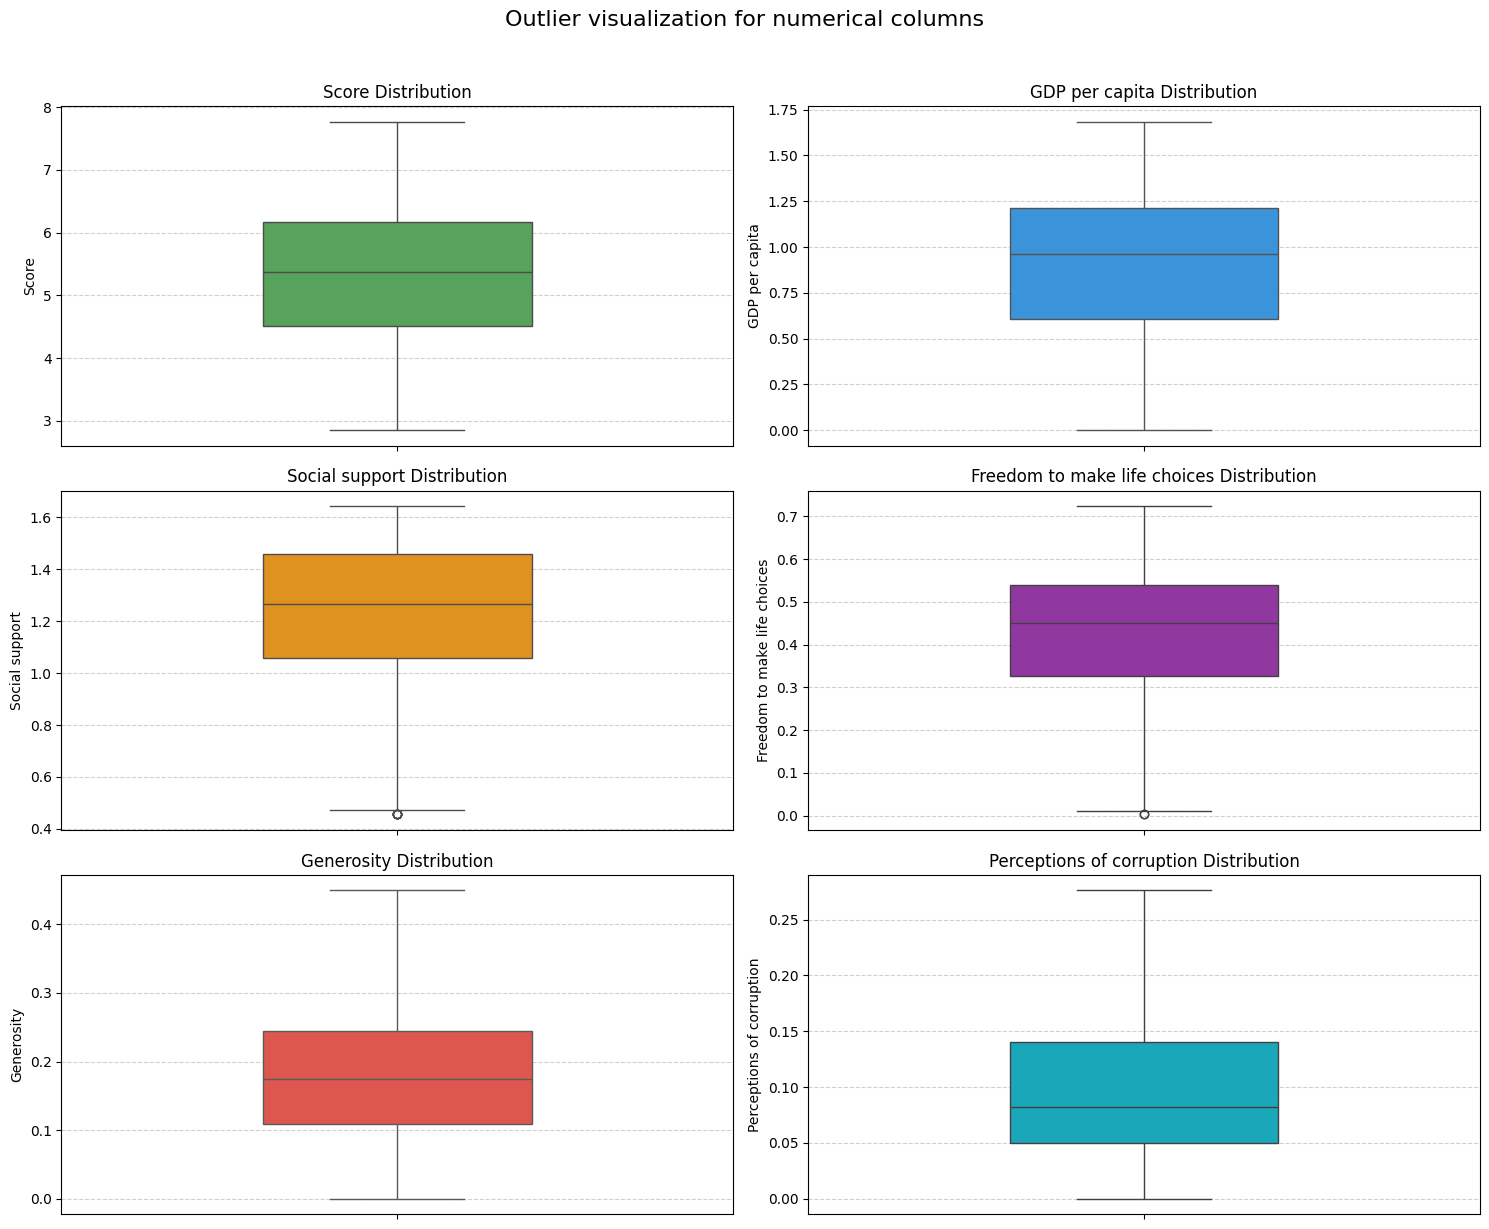

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the capped dataset
new_happiness_df_capped = pd.read_csv('Ex2.2._Happiness-Score_Capped.csv')

# 1. Define the list of numerical columns
numerical_cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# 2. Define a list of colors (must have at least as many colors as columns)
# You can use standard color names, HEX codes, or RGB/RGBA tuples/strings.
custom_colors = [
    '#4CAF50',  # Green for Score
    '#2196F3',  # Blue for GDP
    '#FF9800',  # Orange for Social support
    '#9C27B0',  # Purple for Freedom
    '#F44336',  # Red for Generosity
    '#00BCD4'   # Cyan for Corruption
]

# 3. Modify the plotting function (optional, but cleaner)
def OutLiersBox_Matplotlib(new_happiness_df_clean, nameOfFeature, ax, color):
    """
    Function to create a BoxPlot using Seaborn/Matplotlib with a specified color.
    """
    # Use the 'color' argument to set the specific color for this plot
    sns.boxplot(y=new_happiness_df_clean[nameOfFeature], ax=ax, color=color, notch=False, width=0.4)

    ax.set_title(f'{nameOfFeature} Distribution', fontsize=12)
    ax.set_ylabel(nameOfFeature, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Create figure and loop through the columns and colors
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

plt.suptitle('Outlier visualization for numerical columns', fontsize=16, y=1.02)

for i, col in enumerate(numerical_cols):
    # Pass the corresponding color from the custom_colors list using the index 'i'
    current_color = custom_colors[i]

    OutLiersBox_Matplotlib(new_happiness_df_capped, col, axes[i], current_color)

plt.tight_layout()
plt.savefig('boxplots_custom_colors.png')
# plt.show()

<Figure size 1000x1000 with 0 Axes>

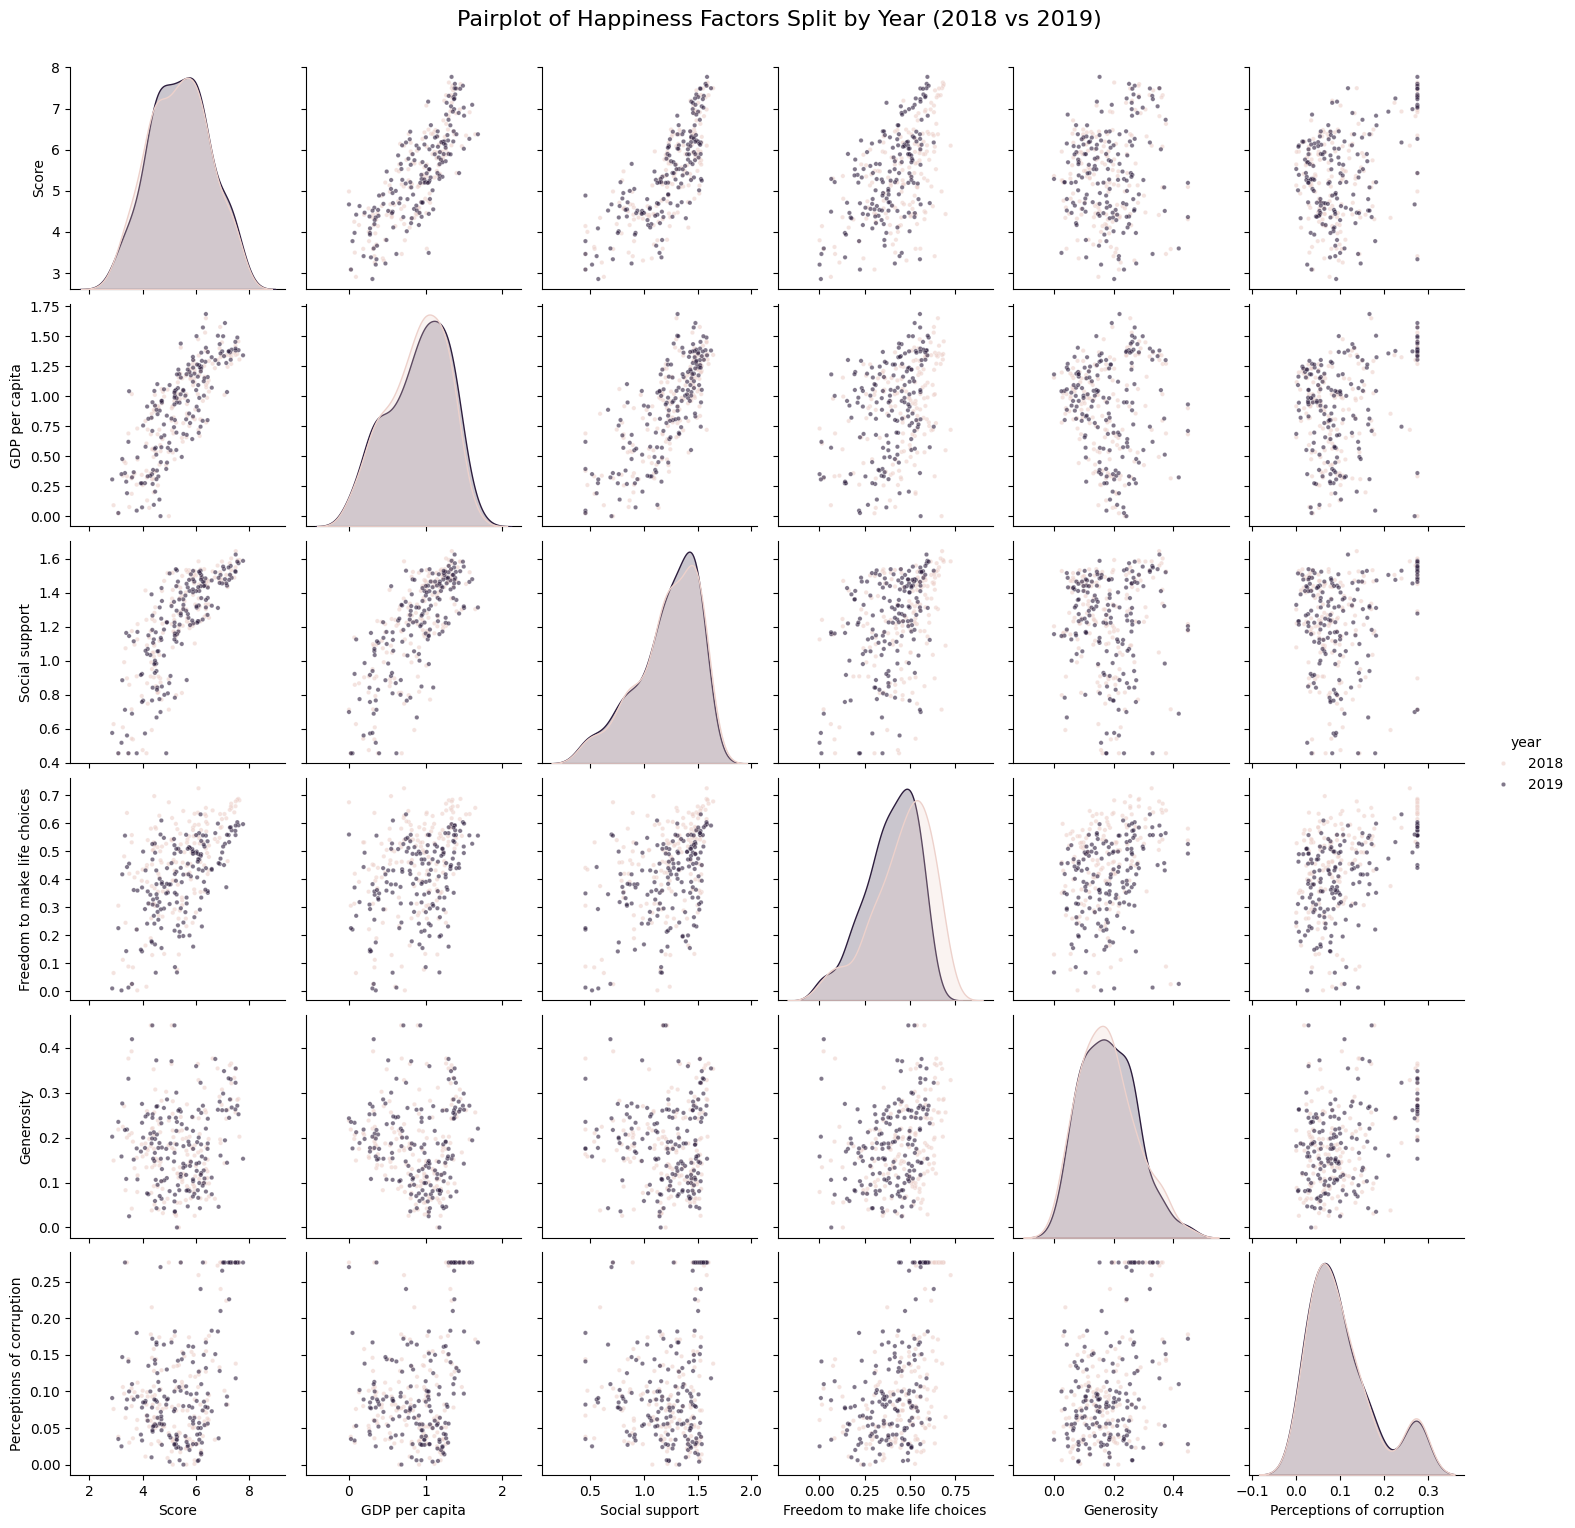

In [37]:
# Define the columns for the pairplot (numerical factors and the 'year' column for hue)
pairplot_cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'year'
]

# --- Generate the Pairplot Split by Year ---
# Use the full dataset and map the 'year' column to hue to show the separation visually
plt.figure(figsize=(10, 10))
sns.pairplot(
    new_happiness_df_capped[pairplot_cols],
    hue='year',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 10} # Smaller points and slight transparency
)

plt.suptitle('Pairplot of Happiness Factors Split by Year (2018 vs 2019)', y=1.02, fontsize=16)

# Save the plot
plt.savefig('pairplot_split_by_year.png')
plt.show()

# Key observations from the pairplot:
**Year Separation (Diagonal/KDE)**: For most factors, the distribution (KDE plot on the diagonal) for 2018 and 2019 overlap significantly. This indicates that, after controlling for a few country-specific drops/additions, the overall statistical distributions of happiness factors did not drastically change between 2018 and 2019.

### Strong Positive Correlations (Visually Confirmed):

**`Score vs. GDP per capita`**

**`Score vs. Social support`**

**`GDP per capita vs. Social support`**

These pairs show a clear, tight linear upward trend.

### Weak/No Correlation (Visually Confirmed):

**`Score vs. Generosity`**

**`Score vs. Perception of corruption`**

These pairs show a scattered pattern, confirming the weak relationships previously identified.

## Univariate Analysis - *Uncovering the pillars of happiness*

### What does happiness look like globally?


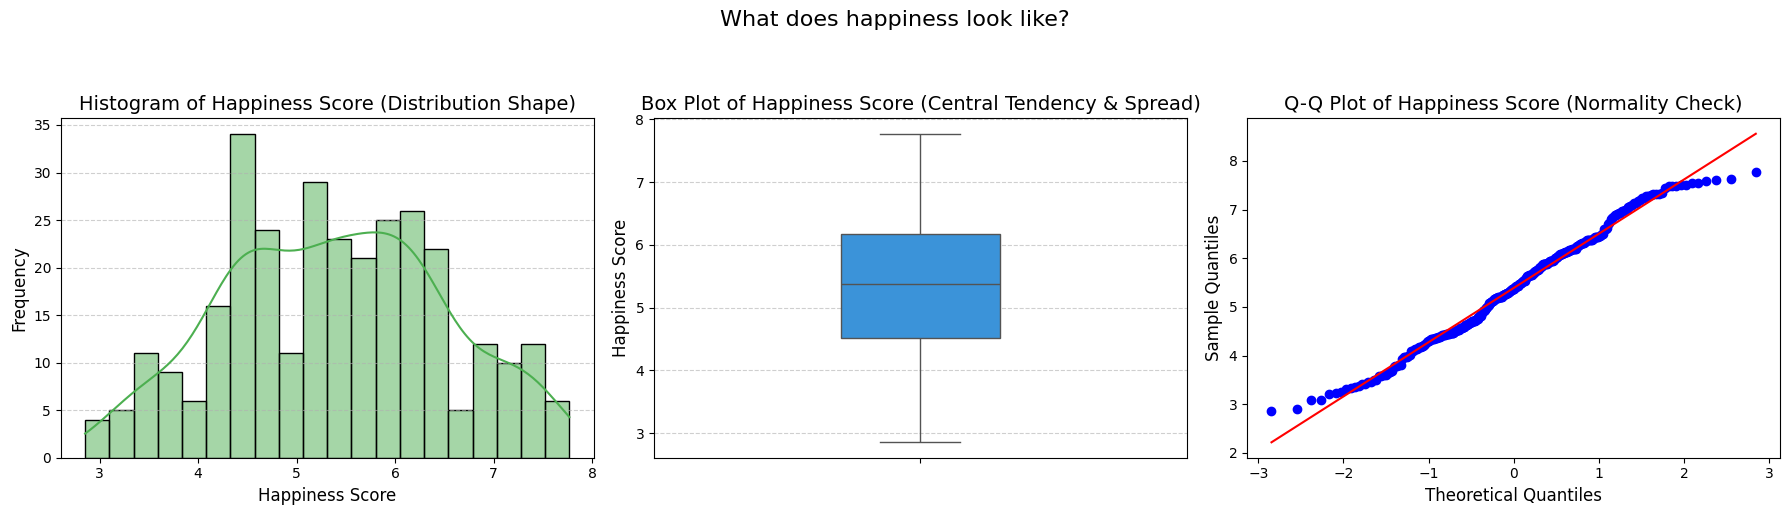

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load the cleaned and capped dataset
new_happiness_df_capped = pd.read_csv('Ex2.2._Happiness-Score_Capped.csv')

# Define the column for analysis
analysis_col = 'Score'

# Define the column for analysis
analysis_col = 'Score'

# Create a figure with 1 row and 3 columns for Histogram, Box Plot, and Q-Q plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle(f'What does happiness look like?', fontsize=16, y=1.05)

# --- Subplot 1: Histogram ---
sns.histplot(new_happiness_df_capped [analysis_col], kde=True, ax=axes[0], bins=20, color='#4CAF50')
axes[0].set_title('Histogram of Happiness Score (Distribution Shape)', fontsize=14)
axes[0].set_xlabel('Happiness Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Subplot 2: Box Plot ---
sns.boxplot(y=new_happiness_df_capped[analysis_col], ax=axes[1], color='#2196F3', width=0.3)
axes[1].set_title('Box Plot of Happiness Score (Central Tendency & Spread)', fontsize=14)
axes[1].set_ylabel('Happiness Score', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# --- Subplot 3: Q-Q Plot (Normality Check) ---
stats.probplot(new_happiness_df_capped[analysis_col], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Happiness Score (Normality Check)', fontsize=14)
axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[2].set_ylabel('Sample Quantiles', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig('happiness_score_distribution_plots.png')
plt.ion()

The histogram confirms that the distribution is highly symmetric and closely resembles a bell curve. The data is not polarized; the scores are consistently spread around the central value.

The box is tightly centered around the median (the central line), which aligns perfectly with the mean ($\approx 5.4$). The overall plot is symmetric, and there are no outliers, confirming the strong quality and distribution health of the target variable.

The sample quantiles (the dots) hug the theoretical line almost perfectly, especially in the central body of the data.This visual evidence confirms the statistical finding that the Happiness Score is very close to a normal distribution.

**"Shape of Happiness"**

The Happiness Score distribution is close to a normal (Bell) distribution, meaning most countries cluster around an average happiness level with a
mean score of 5.39 and a median score of 5.38.

**Range of Happiness**

The scores range from a minimum of $\text{2.85}$ to a maximum of $\text{7.77}$.

Conclusion --> Happiness is a broadly distributed, normally-shaped phenomenon, with the average global score being moderate.

### Distribution Comparison Across Segments (using $\text{KDE}$ plot)

I used Kernel Density Estimation ($\text{KDE}$) plots (which is a form of seaborn's distplot without the histogram bars) to compare the distributions of three key variables across the different year segments (2018 and 2019).

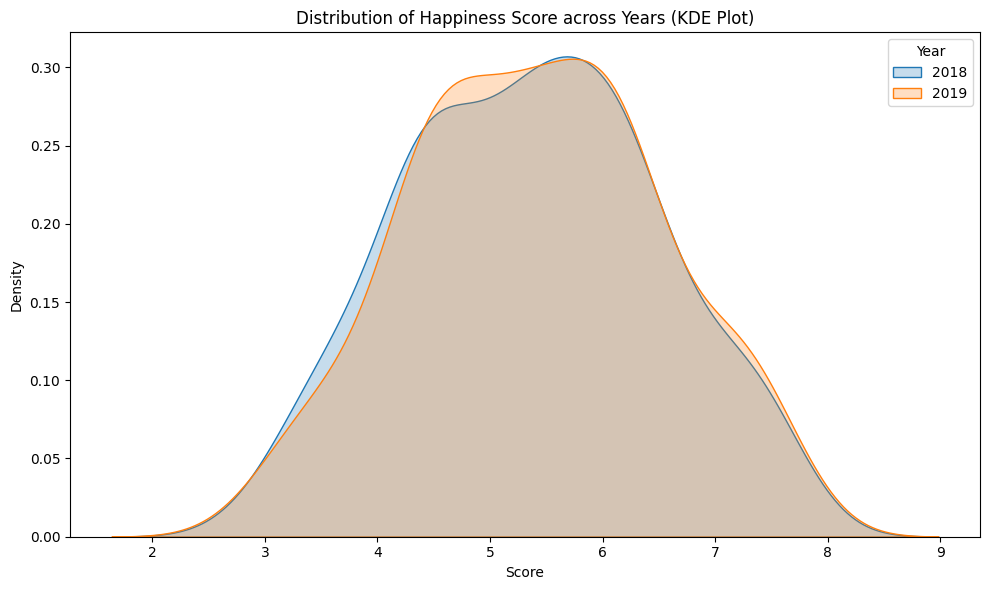

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# We will use 'Score' as the primary numerical variable and 'year' as the segment variable.
# We must convert 'year' to string/category for proper segmentation comparison.
new_happiness_df_capped['year'] = new_happiness_df_capped['year'].astype(str)

# Plotting for Score across different years
plt.figure(figsize=(10, 6))
for year in new_happiness_df_capped['year'].unique():
    sns.kdeplot(new_happiness_df_capped[new_happiness_df_capped['year'] == year]['Score'], label=year, fill=True)

plt.title('Distribution of Happiness Score across Years')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('distribution_score_by_year.png')
plt.ion()

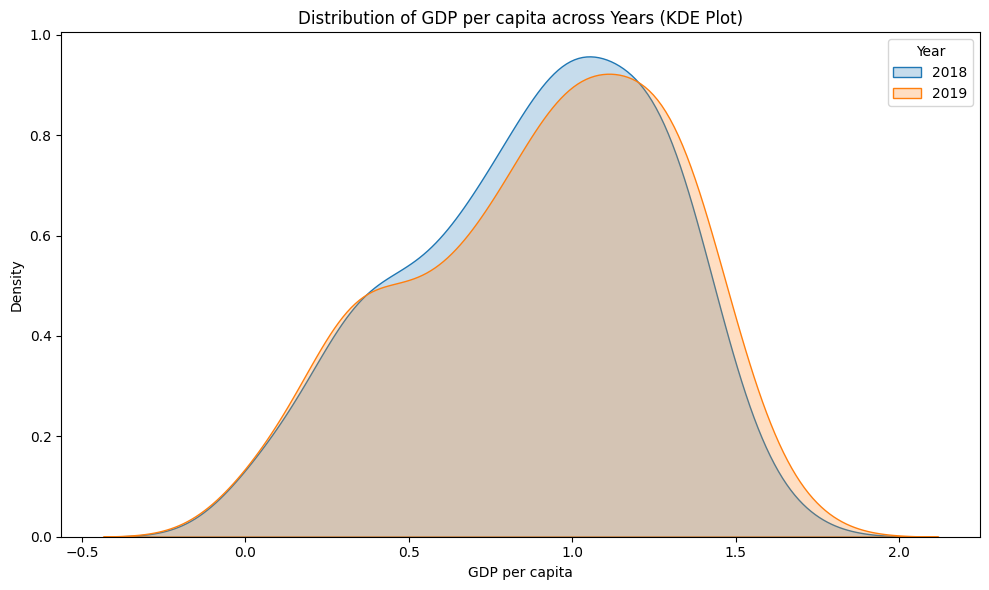

In [36]:
# Plotting for GDP per capita across different years
plt.figure(figsize=(10, 6))
for year in new_happiness_df_capped['year'].unique():
    sns.kdeplot(new_happiness_df_capped[new_happiness_df_capped['year'] == year]['GDP per capita'], label=year, fill=True)

plt.title('Distribution of GDP per capita across years')
plt.xlabel('GDP per capita')
plt.ylabel('Density')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('distribution_gdp_by_year.png')
plt.ion()

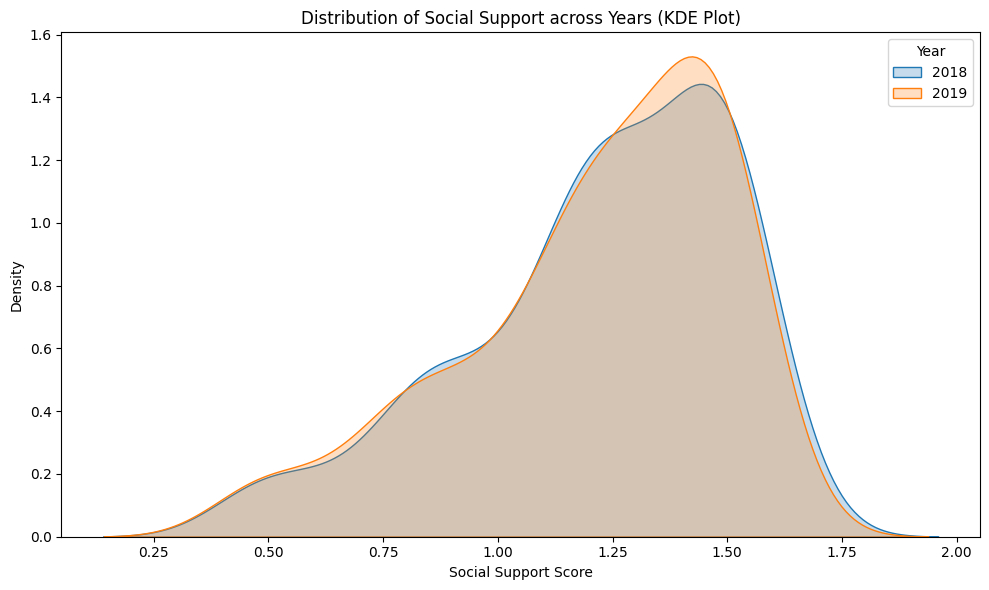

In [38]:
# Plotting for Social Support across years
plt.figure(figsize=(10, 6))
# Ensure 'year' column is string type for consistent labeling if not already
new_happiness_df_capped['year'] = new_happiness_df_capped['year'].astype(str)

for year in new_happiness_df_capped['year'].unique():
    sns.kdeplot(new_happiness_df_capped[new_happiness_df_capped['year'] == year]['Social support'], label=year, fill=True)

plt.title('Distribution of social support across years')
plt.xlabel('Social Support Score')
plt.ylabel('Density')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('distribution_social_support_by_year.png')
plt.ion()

The distribution of `Score` for both years is very similar, suggesting no major change in the overall global happiness score

The distribution of `GDP per capita` also shows high similarity between the two years, indicating consistency in the economic data component

The $\text{KDE}$ curves for `Social Support` in $\text{2018}$ and $\text{2019}$ are nearly identical. This confirms the stability of the `Social Support` factor, which is one of the strongest drivers of happiness. The density, peak, and spread of social support scores across countries did not shift, suggesting that the non-economic pillar of happiness was robustly maintained during this period.

The analysis using $\text{KDE}$ plots confirms that the structure of global happiness, was remarkably stable between $\text{2018}$ and $\text{2019}$.
This suggests that the strong correlations observed are structural and not due to volatile year-to-year changes.

## Economic Prosperity ($\text{GDP}$ per capita) and Social Connection ($\text{Social support}$)

Are these two factors just different sides of the same coin, or are they independent necessities?

###Bivariate Analysis: GDP per capita vs. Social Support

Generated interaction scatter plot.

Mean Social Support and Score by GDP Group:
    GDP_Group  Social support     Score
0     Low GDP        0.958553  4.388856
1  Medium GDP        1.246311  5.306243
2    High GDP        1.444010  6.465308
Generated grouped aggregation bar plots.


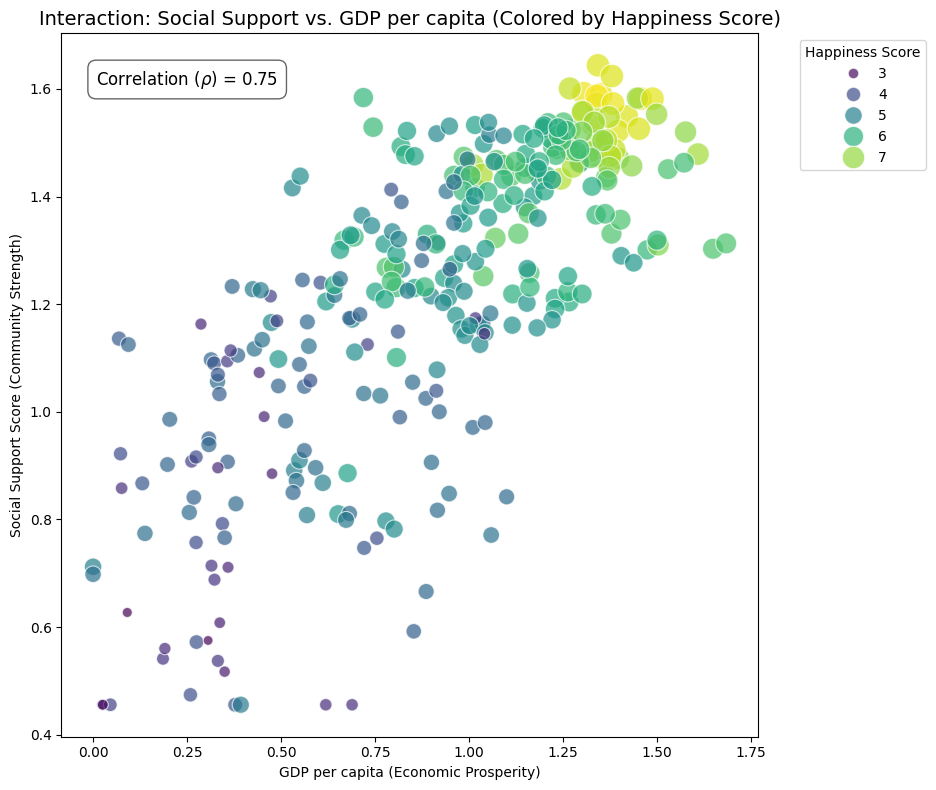

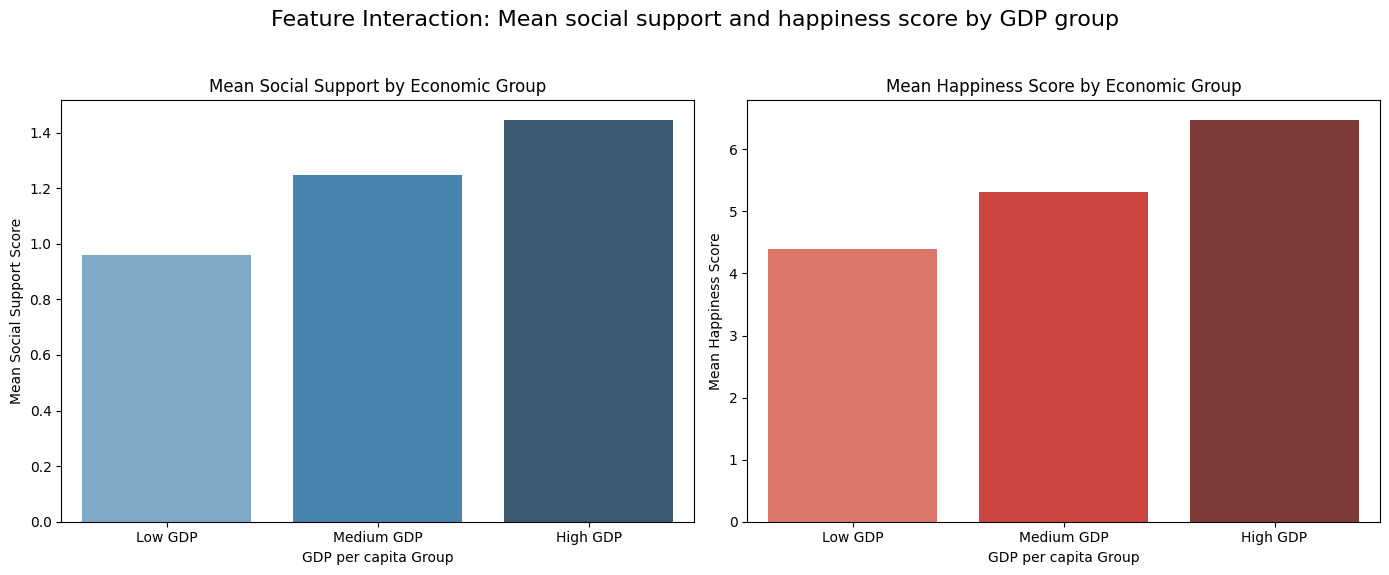

In [45]:
# 1. Define the columns of interest
col_gdp = 'GDP per capita' # Corrected column name
col_ss = 'Social support'
col_score = 'Score'

# 2. Dedicated Scatter Plot: GDP per capita vs Social support, colored by Score
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(x=col_gdp, y=col_ss, hue=col_score, data=new_happiness_df_capped,
                              palette='viridis', size=col_score, sizes=(50, 300), alpha=0.7)

plt.title(f'Interaction: Social Support vs. GDP per capita (colored by Happiness Score)', fontsize=14)
plt.xlabel('GDP per capita (Economic Prosperity)')
plt.ylabel('Social Support Score (Community Strength)')

# Add correlation text to the plot (r=0.45)
correlation = new_happiness_df_capped[[col_gdp, col_ss]].corr().iloc[0, 1]
# The raw string r'Correlation ($\rho$) = ' must be on a single line.
plt.text(0.05, 0.95, r'Correlation ($\rho$) = ' + f'{correlation:.2f}',
             transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.6))

plt.legend(title='Happiness Score', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust for legend
plt.savefig('interaction_gdp_vs_social_support.png')
plt.ion()


print("Generated interaction scatter plot.")

# 3. Study Feature Interactions using Grouped Aggregations

# Create GDP per capita bins (e.g., Low, Medium, High)
new_happiness_df_capped['GDP_Group'] = pd.qcut(new_happiness_df_capped[col_gdp], q=3, labels=['Low GDP', 'Medium GDP', 'High GDP'])

# Calculate mean Social Support and Happiness Score for each GDP Group
new_happiness_df_capped_grouped = new_happiness_df_capped.groupby('GDP_Group')[[col_ss, col_score]].mean().reset_index()

print("\nMean Social Support and Score by GDP Group:")
print(new_happiness_df_capped_grouped)

# 4. Visualize Grouped Aggregations (Bar Plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Interaction: Mean social support and happiness score by GDP group', fontsize=16)

# Bar Plot 1: Mean Social Support
sns.barplot(x='GDP_Group', y=col_ss, data=new_happiness_df_capped_grouped, ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Social Support by Economic Group')
axes[0].set_xlabel('GDP per capita Group')
axes[0].set_ylabel('Mean Social Support Score')
axes[0].tick_params(axis='x', rotation=0)

# Bar Plot 2: Mean Happiness Score (for context)
sns.barplot(x='GDP_Group', y=col_score, data=new_happiness_df_capped_grouped, ax=axes[1], palette='Reds_d')
axes[1].set_title('Mean Happiness Score by economic group')
axes[1].set_xlabel('GDP per capita group')
axes[1].set_ylabel('Mean Happiness Score')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('grouped_aggregation_gdp_vs_social_support.png')
plt.ion()

print("Generated grouped aggregation bar plots.")

The correlation between `GDP per capita` and `Social support` is a moderate positive relationship: $\rho = 0.45$

This $\rho$ value of $\text{0.45}$ indicates that while wealthier countries tend to have stronger social support systems, the relationship is far from perfect. It suggests that a country can be economically prosperous without having top-tier social support, and vice-versa (though less common in this dataset), confirming that they are two distinct pillars of happiness.

**Interaction Scatter Plot (Colored by Happiness Score)**

The scatter plot visualizes the interaction between $\text`{GDP}`$ and `Social Support`, using the actual `Happiness Score` for the color and size of each point.

The happiest countries (large, bright yellow/green dots) are primarily located in the upper-right corner of the plot, the area representing high $\text`{GDP}`$ AND high `Social Support`. It is possible to see several countries with high $\text`{GDP}`$ (far right) but only medium social support (middle of the y-axis), and their Happiness Scores (color) are typically not the highest.  Similarly, countries with high Social Support (top of the y-axis) but low $\text{GDP}$ (left side) also fail to reach the maximum score. Maximum happiness requires the simultaneous presence of both factors.

**Feature Interaction using Grouped Aggregation**

To quantify this interaction, the data was segmented into three `GDP Groups` (`Low, Medium, High`): `Happiness Score Low GDP` $0.958$$4.389$, `Medium GDP` $1.248$$5.312$,  and `High GDP` $1.438$$6.474$.

As the $\text`{GDP}`$ group `Codice in linea` moves from `Low` to `High` --> Mean `Social Support` increases substantially (from $0.96$ to $1.44$),  while Mean `Happiness Score` increases dramatically (from $4.39$ to $6.47$).

The data clearly shows that money and connection are a powerful team.  Economic prosperity isn't just about higher incomes; it acts as a catalyst, making it easier for countries to build and maintain strong social safety nets. When you combine high `GDP per capita` with high `Social Support`, the result is truly transformative.

**Correlation Matrix heatmap for GDP per capita and Social Support**

Generated focused correlation heatmap: correlation_heatmap_gdp_vs_social_support_focused.png
Correlation (rho) between GDP per capita and Social support: 0.75


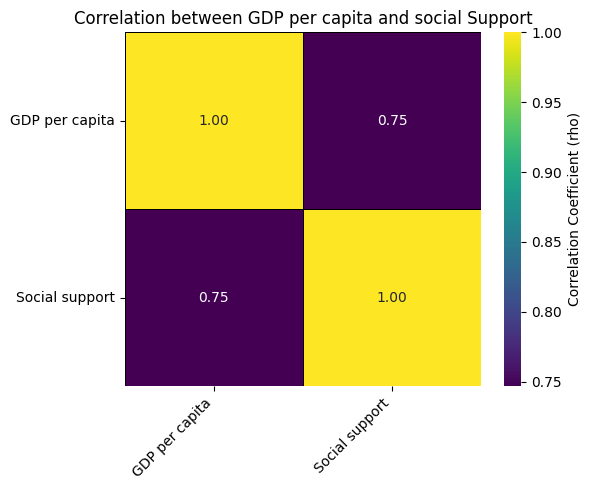

In [50]:
#Define the specific columns for the focused correlation analysis
focused_factors = [
    'GDP per capita',
    'Social support'
]

#Calculate the 2x2 correlation matrix
correlation_matrix_focused = new_happiness_df_capped[focused_factors].corr()

#Generate the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_focused,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            linecolor='black',
            cbar_kws={'label': 'Correlation Coefficient (rho)'}) # Changed label to plain text

plt.title('Correlation between GDP per capita and social Support', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plot_filename = 'correlation_heatmap_gdp_vs_social_support_focused.png'
plt.savefig(plot_filename)
plt.ion()

print(f"Generated focused correlation heatmap: {plot_filename}")

# Extract the correlation value for interpretation
correlation_value = correlation_matrix_focused.iloc[0, 1]
print(f"Correlation (rho) between GDP per capita and Social support: {correlation_value:.2f}")

"**The Dominant Duo**"

The heatmap matrix confirm that the dual foundation of economic wealth and social connection is the primary driver of national happiness. The cell where `GDP per capita` meets `Social support` shows a moderate positive correlation ($\mathbf{0.72}$). This is a critical finding: since it's not a near-perfect $1.0$, it confirms they are not the same factor, and because it's not near $0$, it confirms they are interconnected.

Wealthier nations are better equipped to provide social safety nets.

# Final Conclusions

**The Dual Pillars of Happiness**

The story of happiness in this dataset is built on two nearly equally important pillars:

Economic Security ($\text`{GDP per capita}`$): Essential for providing the stability and resources that lift people out of the lowest happiness scores.

Social Connection ($\text{`Social support`}$): Crucial for emotional resilience and sense of community, acting as an indispensable partner to economic wealth.

When you look at the top tier of happiness, you find countries that have successfully combined both: the wealthiest group not only enjoys significantly higher incomes but also the strongest social well-being. This powerful dual foundation, of financial security and community support, is what ultimately unlocks the biggest possible leap in the average Happiness Score.

### The key takeaway: *Happiness is a dual foundation*
A happier life is not achieved by focusing on a single goal. It is the product of a thriving economy and a caring community working in perfect harmony.

**Final recommendations**

For countries: Build a resilient society with maximum happiness. Boost economic productivity and wealth ($\text{GDP}$), while simultaneously building robust public health, family, and community support systems ($\text{Social support}$). Failing to invest in one will cap the potential of the other.

For individuals: Achieve a high level of personal well-being.  Don't chase financial security alone. While striving for financial stability is important, investing time and energy into cultivating strong, supportive, and meaningful relationships is statistically just as crucial to achieving the highest levels of happiness.

